# Paso 1. Preparación de baseline

Flujo clásico (SVM) que arma el baseline: carga de datos, análisis exploratorio, tratamiento (partición, imputación, escalado), modelización SVM (selección de variables, hiperparámetros, modelo final) y guardado de los datasets/muestreo/variables que usan los pasos posteriores (kernel cuántico).

## 1.1 Importación de librerías y datos base

In [39]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

from funciones import (
    graficar_box_hist_grid,
    graficar_metricas_forward,
    evaluar_forward,
    graficar_matrices_confusion,
    classification_metrics,
    comparar_metricas_train_test,
    guardar_datasets_excel,
    asignar_muestreo_balanceado,
    guardar_muestreo_excel,
)

import os

# Figuras: carpeta unica de salida, con nombre "{paso:02d}_{seccion:02d}_{descripcion}.png"
# (paso = parte del flujo dentro del cuaderno, 01 = SVM clasico; seccion = orden de
# aparicion de la figura dentro de ese paso).
IMG_DIR = "data/img"
os.makedirs(IMG_DIR, exist_ok=True)

In [40]:
df = pd.read_csv('./data/raw/water_potability.csv',sep=",")

## 1.2 Análisis de datos

In [41]:
features = df.drop(columns=['Potability']).columns.tolist()
objetivo = 'Potability'
line = "baseline"

### 1.2.1 Análisis de variables

In [42]:
resumen_variables = (df[features].describe().T.drop(columns="count").rename(columns={    "mean": "promedio",    "std": "desviacion_estandar",    "min": "minimo",    "25%": "percentil_25",    "50%": "mediana",    "75%": "percentil_75",    "max": "maximo",})
)

resumen_variables.insert(0,"cantidad_vacios",df[features].isna().sum())
resumen_variables.insert(1,"porcentaje_vacios",df[features].isna().mean() * 100)

resumen_variables.style.format({"porcentaje_vacios": "{:.2f}%","promedio": "{:,.2f}","desviacion_estandar": "{:,.2f}","minimo": "{:,.2f}","percentil_25": "{:,.2f}","mediana": "{:,.2f}","percentil_75": "{:,.2f}","maximo": "{:,.2f}",
}).set_caption("Resumen descriptivo de las variables")

,cantidad_vacios,porcentaje_vacios,promedio,desviacion_estandar,minimo,percentil_25,mediana,percentil_75,maximo
ph,491,14.99%,7.08,1.59,0.00,6.09,7.04,8.06,14.00
Hardness,0,0.00%,196.37,32.88,47.43,176.85,196.97,216.67,323.12
Solids,0,0.00%,"22,014.09","8,768.57",320.94,"15,666.69","20,927.83","27,332.76","61,227.20"
Chloramines,0,0.00%,7.12,1.58,0.35,6.13,7.13,8.11,13.13
Sulfate,781,23.84%,333.78,41.42,129.00,307.70,333.07,359.95,481.03
Conductivity,0,0.00%,426.21,80.82,181.48,365.73,421.88,481.79,753.34
Organic_carbon,0,0.00%,14.28,3.31,2.20,12.07,14.22,16.56,28.30
Trihalomethanes,162,4.95%,66.40,16.18,0.74,55.84,66.62,77.34,124.00
Turbidity,0,0.00%,3.97,0.78,1.45,3.44,3.96,4.50,6.74


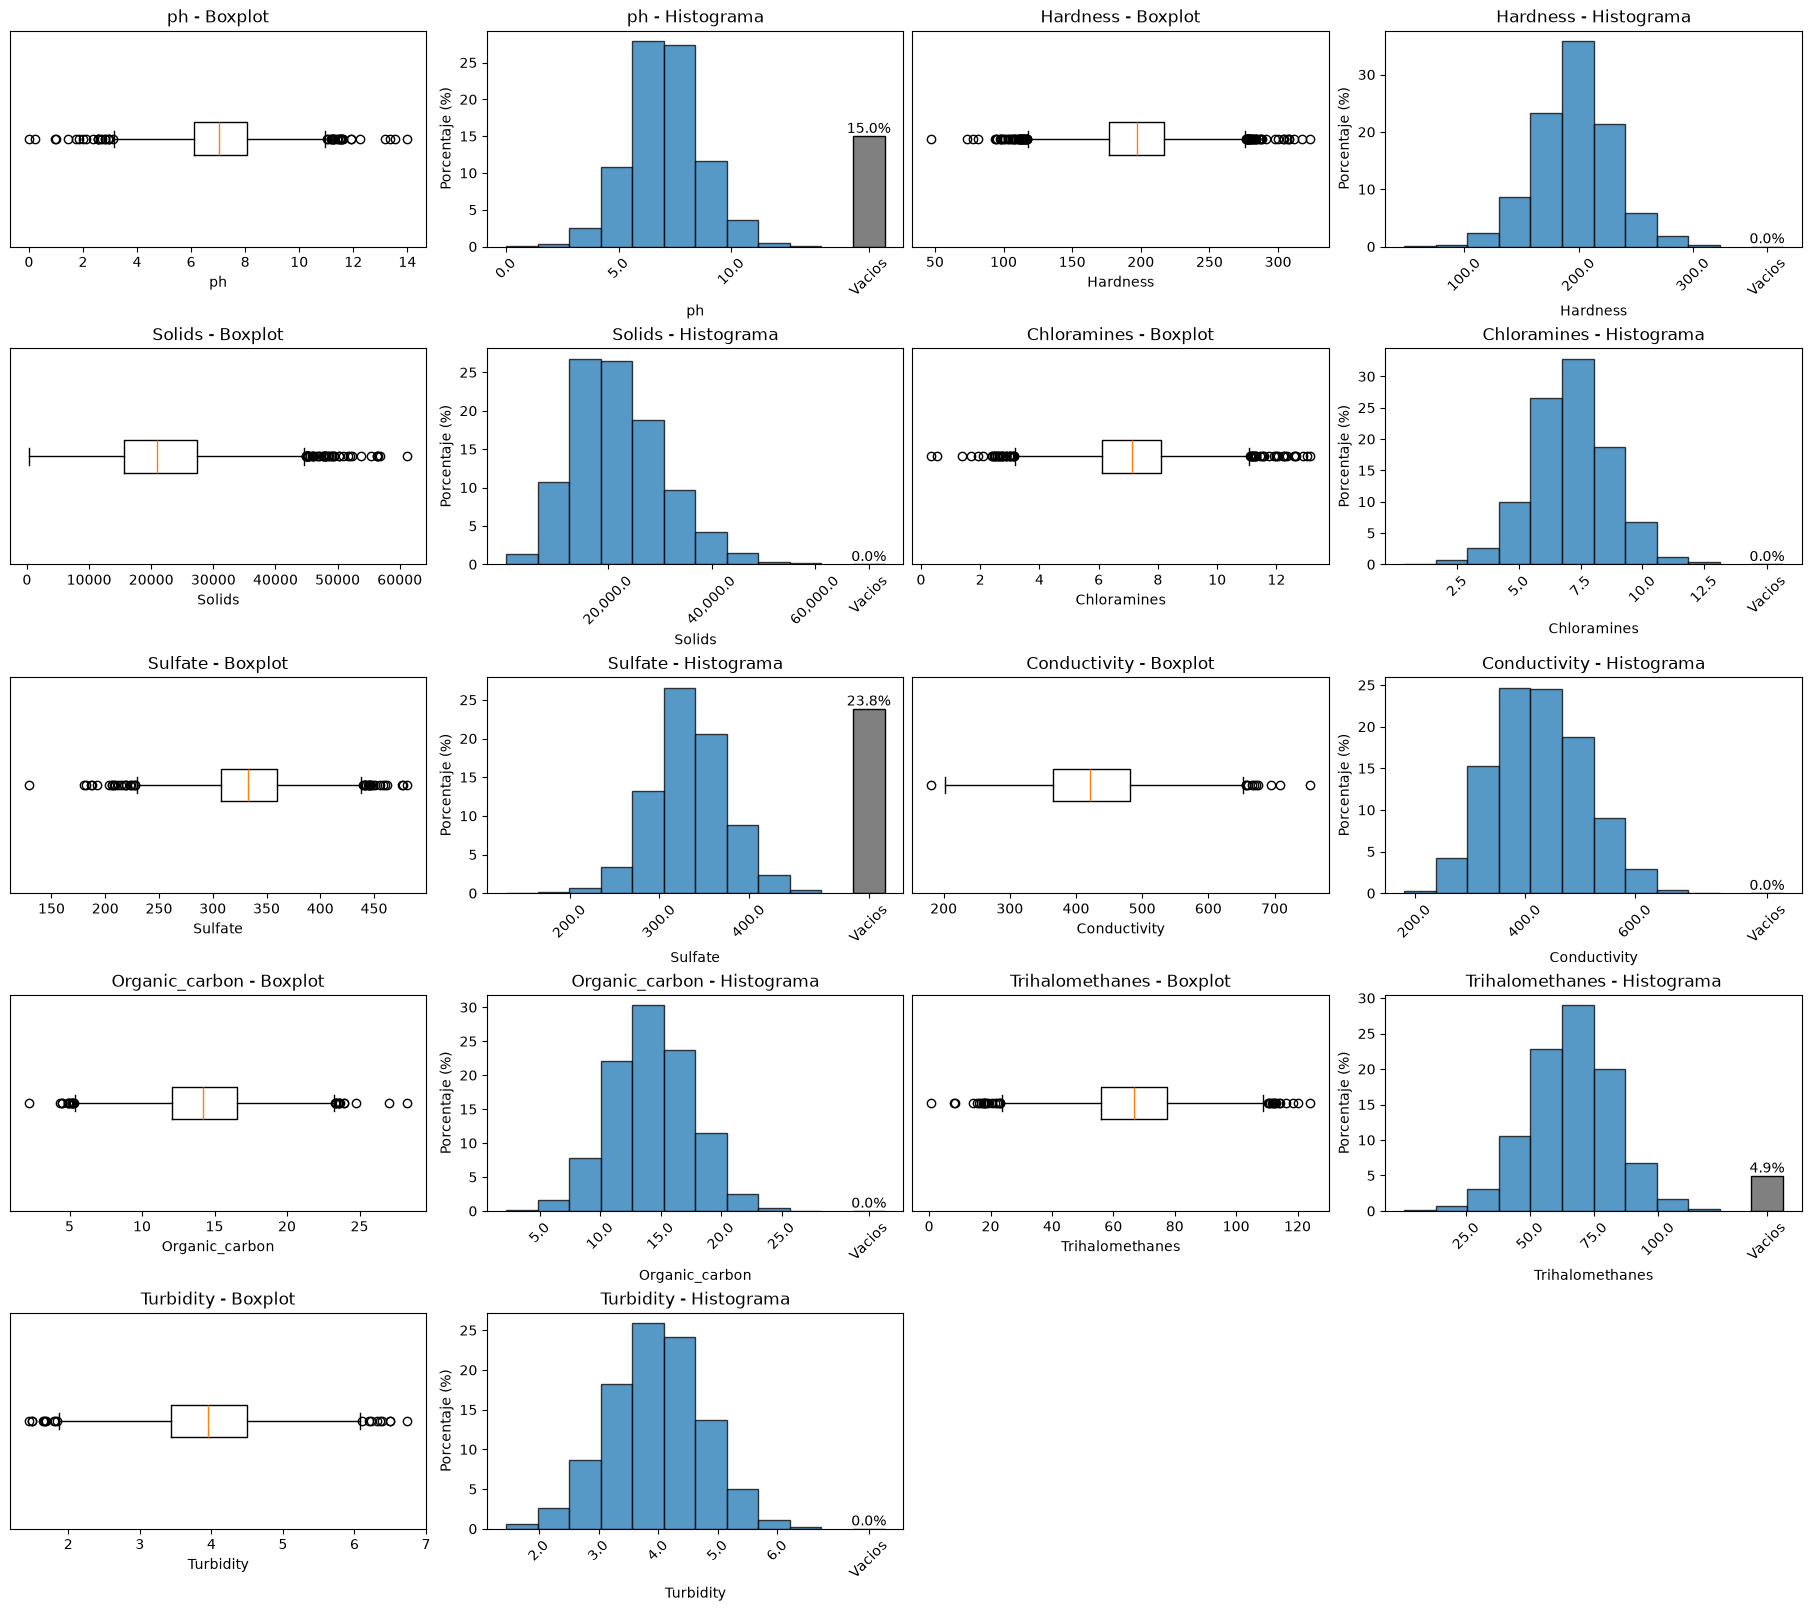

In [43]:
fig, axes = graficar_box_hist_grid(df, features, variables_por_fila=2, num_bins=10)
fig.savefig(f"{IMG_DIR}/01_01_boxplot_histograma.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.3 Tratamiento de datos
Previo a realiar la imputación , escalado o balanceado de datos, es importante separar la data test, de lo contrario puede afectar en las decisiones del entrenamiento. Esto se decide por el posible data leakage

In [44]:
x = df.drop(columns=['Potability']).copy()
y = df['Potability'].copy()

### 1.3.1 División estratificada

In [45]:
X_train, X_test, y_train, y_test = train_test_split(x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, f"{y_train.mean()*100:.2f}% (potability = 1)")
print("Test :", X_test.shape, f"{y_test.mean()*100:.2f}% (potability = 1)")

Train: (2620, 9) 39.01% (potability = 1)
Test : (656, 9) 39.02% (potability = 1)


### 1.3.2 Imputación de datos y el no uso de Undersampling
Para esta seccion se procederá a realizar imputación de datos, ya que existen features con valores vacíos, estos no son trabajables para el kernel cuántico (ni clasico). Además, es necesario que esta imputación se realice luego de la separación train/test, ya que se deben usar las medianas de la PARTE TRAIN. 

Por el lado de Undersampling es innecesario su uso ya que la tasa del evento es 60/40, lo que no corresponde a tener data desbalanceada, caso que si puede ser al llegar a muestras 70/30 u 80/20.

In [46]:
#Imputación features con vacíos (ph,sulfato, trihalometanos)
medianas_train = X_train.median()
X_train = X_train.fillna(medianas_train)
X_test = X_test.fillna(medianas_train)

### 1.3.3 Estandarización a promedio 1 y var 0

In [47]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

## 1.4 Modelización clásica SVM

### 1.4.1 Selección de variables por forward
A continuación se revisa el número de variables que deberían usarse , en donde el costo sea tan alto, donde no se note una mejora de f1 ni auc

#### 1.4.1.1 Hiperparámetros modelo

In [48]:
svm = SVC(kernel="rbf",
          gamma="auto",
          C=10,
          class_weight="balanced",
          random_state=42,  # misma semilla del cuaderno; sin efecto hoy (probability=False),
                            # pero fija por si se activa estimacion de probabilidades
          )

#Validación Cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### 1.4.1.2 Selección de variables por forward

In [49]:
resultados_forward = evaluar_forward(
    X=X_train, y=y_train,
    modelo=svm,
    cv=cv
)

resultados_forward

[evaluar_forward] Cache existente en 'cache\evaluar_forward_5a2d3c3b8d6e7d91341a22b358009f62.json': se cargan los resultados guardados.


,numero_variables,variables,f1_cv,auc_cv,recall_cv
0,1,[ph],0.514045,0.521545,0.710392
1,2,"[ph, Hardness]",0.536311,0.561519,0.718168
2,3,"[ph, Hardness, Chloramines]",0.510280,0.573809,0.619235
3,4,"[ph, Hardness, Chloramines, Sulfate]",0.543251,0.687922,0.525509
4,5,"[ph, Hardness, Solids, Chloramines, Sulfate]",0.583949,0.720728,0.569436
5,6,"[ph, Hardness, Solids, Chloramines, Sulfate, C...",0.574632,0.714710,0.574376
6,7,"[ph, Hardness, Solids, Chloramines, Sulfate, C...",0.579468,0.709219,0.585093
7,8,"[ph, Hardness, Solids, Chloramines, Sulfate, C...",0.568922,0.708680,0.573343
8,9,"[ph, Hardness, Solids, Chloramines, Sulfate, C...",0.563011,0.694906,0.581162


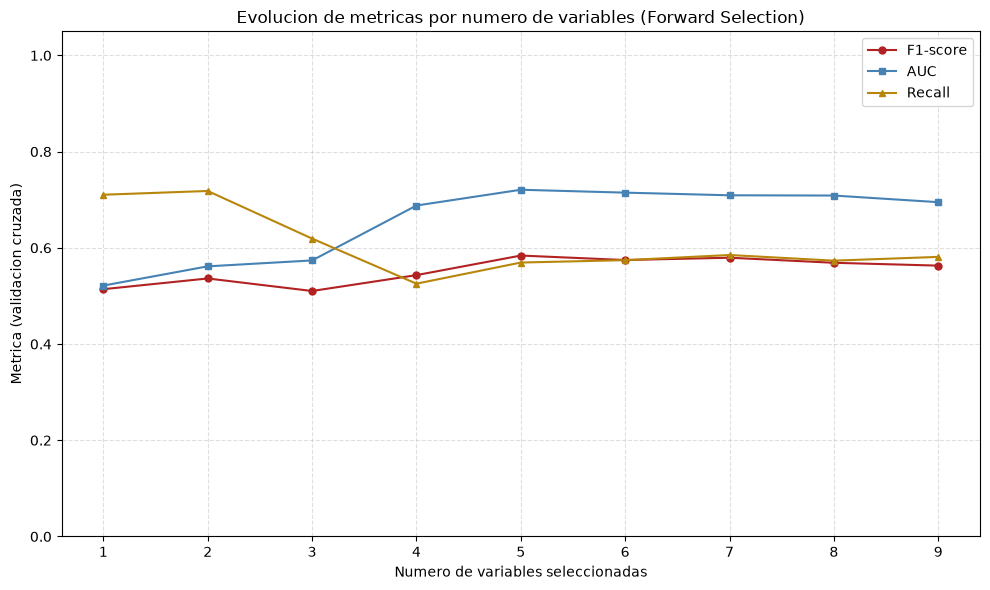

In [50]:
fig, ax = graficar_metricas_forward(resultados_forward)
fig.savefig(f"{IMG_DIR}/01_02_metricas_forward.png", dpi=150, bbox_inches="tight")
plt.show()

#### 1.4.1.3 Modelo final con n_vars seleccionado

In [51]:
n_vars= 5

print("Variables seleccionadas:")
variables_finales = resultados_forward.iloc[n_vars-1]["variables"]
print(variables_finales)

#Se toman los dataset unicamente de las variables finales
X_train_selected = X_train[variables_finales].copy()
X_test_selected = X_test[variables_finales].copy()

Variables seleccionadas:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate']


### 1.4.2 Optimización de hiperparámetros de selección final

In [52]:
from funciones import evaluar_grid_search

# Hiperparametros que se van a probar
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto", 0.01],
}

scoring_grid = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
}

# Se encuentran los hiperparametros optimos en donde no sufra un overfitting el
# modelo. Esta busqueda siempre da el mismo resultado, asi que se cachea igual
# que evaluar_forward: no hace falta esperar la ejecucion completa cada vez.
cv_results_full, classical_model, mejores_parametros = evaluar_grid_search(
    X=X_train_selected,
    y=y_train,
    modelo=svm,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring_grid,
    refit="f1",
)

cv_results = (
    cv_results_full[[
        "param_C",
        "param_gamma",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "rank_test_f1",
    ]]
    .sort_values("rank_test_f1")
)

[evaluar_grid_search] Cache existente en 'cache\evaluar_grid_search_ad6691591fba7a954f5e681943c70cb0.json': se cargan los resultados guardados.


In [53]:
cv_results.head(1)

,param_C,param_gamma,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_f1
7,10.0,auto,0.683588,0.600662,0.569436,0.583949,1


### 1.4.3 Modelización final

In [54]:
# classical_model ya viene de evaluar_grid_search (celda anterior), reentrenado con mejores_parametros.

# Predicciones en train
y_pred_train = classical_model.predict(X_train_selected)
y_score_train = classical_model.decision_function(X_train_selected)

classical_metrics_train = classification_metrics(
    y_train,
    y_pred_train,
    y_score_train
)

# Predicciones en test
y_pred_test = classical_model.predict(X_test_selected)
y_score_test = classical_model.decision_function(X_test_selected)

classical_metrics_test = classification_metrics(
    y_test,
    y_pred_test,
    y_score_test
)

comparar_metricas_train_test(classical_metrics_train, classical_metrics_test)

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,0.745,0.663,0.082,10.95%
precision,0.690,0.581,0.109,15.80%
recall,0.628,0.492,0.136,21.65%
f1,0.657,0.533,0.125,18.96%
roc_auc,0.808,0.693,0.115,14.28%


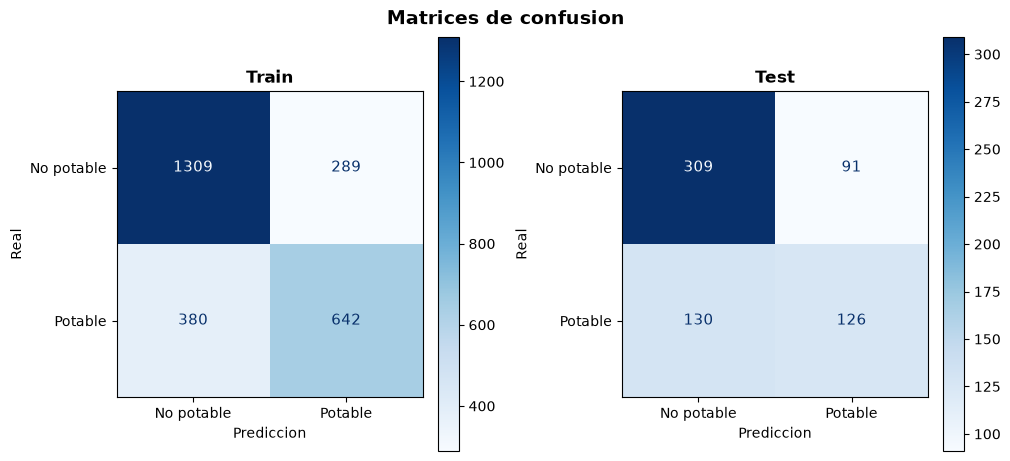

In [55]:
fig, axes = graficar_matrices_confusion(y_train, y_pred_train, y_test, y_pred_test)
fig.savefig(f"{IMG_DIR}/01_03_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.5 Guardado de datasets (originales, imputados, normalizados)
Se guarda un unico Excel con tres hojas (`originales`, `imputados`, `normalizados`), cada una con train y test unificados (X + Y). `_PartInd_` distingue train (0) de test (1); `_Imputation_` marca si la fila tuvo algun valor imputado (1) o no (0); `_ImputationCol_` indica que columna(s) se imputaron, separadas por coma si es mas de una.

In [56]:
ruta_excel = guardar_datasets_excel(
    df=df,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    scaler=scaler,
    features=features,
    objetivo=objetivo,
    ruta_excel="data/processed/dataset_v1.xlsx"
)

print(f"Guardado en {ruta_excel}")

Guardado en data/processed/dataset_v1.xlsx


## 1.6 Muestreo jerarquico balanceado (`_Muestreo_`)

Sobre la tabla normalizada se agrega la columna `_Muestreo_`, que marca el nivel mas profundo de submuestra **anidada y balanceada** (50/50 en `Potability`, no estratificada) al que llega cada fila:

- `_PartInd_ = 0` (train): `1` = muestra de 64, `2` = submuestra de 32, `3` = submuestra de 16.
- `_PartInd_ = 1` (test): `1` = muestra de 32, `2` = submuestra de 16, `3` = submuestra de 8.
- `0` = fuera de la muestra.

Por el anidamiento, la muestra de nivel `k` son las filas con `_Muestreo_ >= k`.

**Regla de datos virgenes:** el muestreo se hace unicamente sobre filas sin imputacion (`_Imputation_ == 0`); al usar pocas filas nos centramos en datos que no fueron tocados por la imputacion. La regla vive dentro de `asignar_muestreo_balanceado` (`funciones.py`).

In [57]:
# Reconstruye la tabla normalizada (features + Potability + _PartInd_) desde train/test,
# con la marca _Imputation_ (1 si la fila tuvo algun valor imputado) calculada igual
# que en guardar_datasets_excel: nulos del df crudo en las columnas imputables.
columnas_imputables = ["ph", "Sulfate", "Trihalomethanes"]
imputacion_train = df.loc[X_train.index, columnas_imputables].isna().any(axis=1).astype(int)
imputacion_test = df.loc[X_test.index, columnas_imputables].isna().any(axis=1).astype(int)

tabla_normalizados = pd.concat([
    X_train.assign(**{objetivo: y_train.values, "_PartInd_": 0, "_Imputation_": imputacion_train.values}),
    X_test.assign(**{objetivo: y_test.values, "_PartInd_": 1, "_Imputation_": imputacion_test.values}),
], ignore_index=True)

# Muestreo jerarquico balanceado sobre filas virgenes (_Imputation_ == 0);
# la logica y la regla viven en funciones.py.
tabla_normalizados = asignar_muestreo_balanceado(
    tabla_normalizados,
    tamanos_por_particion={0: [64, 32, 16], 1: [32, 16, 8]},
    objetivo=objetivo,
    random_state=42,  # misma semilla que train_test_split, fija para reproducir este analisis
)

tabla_normalizados = tabla_normalizados[tabla_normalizados["_Muestreo_"]!=0]

# Conteo de filas por particion y nivel de muestreo.
display(tabla_normalizados.groupby(["_PartInd_", "_Muestreo_"]).size().unstack(fill_value=0))

# Agrega la hoja "muestreos" al Excel ya generado (ruta_excel, celda anterior).
# _Imputation_ se descarta: tras la regla todas las filas guardadas son virgenes.
guardar_muestreo_excel(tabla_normalizados.drop(columns="_Imputation_"), ruta_excel)
print(f"Hoja 'muestreos' guardada en {ruta_excel}")

_Muestreo_,1,2,3
_PartInd_,,,
0,32,16,16
1,16,8,8


Hoja 'muestreos' guardada en data/processed/dataset_v1.xlsx


## 1.7 Guardado de variables seleccionadas

Se agrega al archivo Excel la hoja `variables`, que contiene el listado de las variables seleccionadas para el entrenamiento de los modelos. Cada variable se registra en una fila bajo la columna `_vars_`. Si la hoja ya existe, se reemplaza para evitar registros duplicados.

In [58]:
tabla_variables = pd.DataFrame({
    "_vars_": X_train_selected.columns.tolist()
})

with pd.ExcelWriter(
    ruta_excel,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace",
) as writer:
    tabla_variables.to_excel(
        writer,
        sheet_name="variables",
        index=False,
    )

print(f"Hoja 'variables' guardada en {ruta_excel}")
display(tabla_variables)

Hoja 'variables' guardada en data/processed/dataset_v1.xlsx


,_vars_
0,ph
1,Hardness
2,Solids
3,Chloramines
4,Sulfate


# Paso 2. Kernel cuantico

Define las familias de modelos (feature map x tamano de muestra) que se van a generar con el kernel cuantico, a partir de los datos y variables guardados en el Paso 1.

## 2.1 Familias de modelos

In [59]:
# Familias de modelos, definidas a mano (feature_map, tamano) o
# (feature_map, tamano, ruta_train, ruta_test). El kernel se guarda en
# dos archivos separados (matriz de train y matriz de test), por lo que
# cada uno se declara por separado. ruta_train/ruta_test son la ruta
# (str) al csv ya calculado en una ejecucion anterior, o "" si esa
# matriz especifica todavia no existe:
#   - ambas presentes  -> familia completa, no se calcula nada.
#   - solo ruta_train  -> falta calcular la matriz de test.
#   - solo ruta_test   -> falta calcular la matriz de train.
#   - sin 3er/4to elemento -> ambas pendientes de calcular.
FAMILIAS = [
    ("zz", 16, "data/runs/ZZ_Train_16.csv","data/runs/ZZ_Test_16.csv"),
    ("zz", 32, "data/runs/ZZ_Train_32.csv","data/runs/ZZ_Test_32.csv"),
    ("zyy", 16, "data/runs/zyy_Train_16.csv","data/runs/zyy_Test_16.csv"),
    ("zyy", 32, "data/runs/zyy_Train_32.csv","data/runs/zyy_Test_32.csv"),
    ("ry_cx_rx", 16, "data/runs/Custom_Train_16.csv","data/runs/Custom_Test_16.csv"),
    ("ry_cx_rx", 32, "data/runs/Custom_Train_32.csv","data/runs/Custom_Test_32.csv"),
]

In [60]:
from funciones import parsear_familia

print(f"{len(FAMILIAS)} familias:")
for familia in FAMILIAS:
    feature_map, tamano, ruta_train, ruta_test = parsear_familia(familia)
    if ruta_train and ruta_test:
        estado = "completa (train y test ya calculados)"
    elif ruta_train:
        estado = f"falta test (train: {ruta_train})"
    elif ruta_test:
        estado = f"falta train (test: {ruta_test})"
    else:
        estado = "pendiente (train y test por calcular)"
    print(f"  - {feature_map}_{tamano}: {estado}")

6 familias:
  - zz_16: completa (train y test ya calculados)
  - zz_32: completa (train y test ya calculados)
  - zyy_16: completa (train y test ya calculados)
  - zyy_32: completa (train y test ya calculados)
  - ry_cx_rx_16: completa (train y test ya calculados)
  - ry_cx_rx_32: completa (train y test ya calculados)


In [61]:
# Nivel de muestreo (_Muestreo_) correspondiente a cada tamano de train.
# El muestreo es anidado (_Muestreo_ >= nivel): un tamano mayor no es un
# nivel independiente, sino el nivel que ya envuelve (incluye) al de un
# tamano menor. Por eso no puede ser una sola constante global: cada
# tamano necesita resolver su propio nivel.
from funciones import nivel_muestreo

NIVEL_POR_TAMANO = {
    16: 3,
    32: 2,
}

## 2.2 Datos que alimentan a los modelos

Para cada familia, cuenta cuantos registros de train/test le corresponden (segun el nivel de muestreo de su `tamano`, hoja `muestreos`) y confirma la dimension cuantica (numero de qubits), que es la cantidad de variables seleccionadas en el Paso 1.

In [62]:
from funciones import contar_registros_familia

muestreo_df = pd.read_excel(ruta_excel, sheet_name="muestreos")

# Dimension cuantica: un qubit por variable seleccionada en el Paso 1 (1.4.1.3).
N_QUBITS = len(variables_finales)

resumen_datos = []
for familia in FAMILIAS:
    feature_map, tamano, ruta_train, ruta_test = parsear_familia(familia)
    n_train, n_test = contar_registros_familia(tamano, NIVEL_POR_TAMANO, muestreo_df)
    resumen_datos.append({
        "Familia": f"{feature_map}_{tamano}",
        "Registros train": n_train,
        "Registros test": n_test,
        "Dimension cuantica (qubits)": N_QUBITS,
    })

display(pd.DataFrame(resumen_datos))

,Familia,Registros train,Registros test,Dimension cuantica (qubits)
0,zz_16,16,8,5
1,zz_32,32,16,5
2,zyy_16,16,8,5
3,zyy_32,32,16,5
4,ry_cx_rx_16,16,8,5
5,ry_cx_rx_32,32,16,5


## 2.3 Inspeccion del feature map U(x)

Revisa los circuitos U(x) y U(x) dagger de las 3 familias de feature map, apilados uno debajo del otro (cada uno navegable con su propio zoom/scroll). El tamano de muestra (16 vs 32) no cambia el circuito, solo cuantos pares se corren despues, asi que basta un vector de ejemplo por feature map.

In [63]:
from funciones import construir_circuitos_ejemplo

# Vector de ejemplo: misma fila para las 3 familias (solo cambia el feature map).
FILA_EJEMPLO = 0
x_ejemplo = X_train_selected.iloc[FILA_EJEMPLO].to_numpy(dtype=float)

circuitos_u, circuitos_u_dagger = construir_circuitos_ejemplo(x_ejemplo, N_QUBITS)

In [64]:
from funciones import mostrar_inspeccion_feature_map

mostrar_inspeccion_feature_map(circuitos_u, circuitos_u_dagger)

## 2.4 Cargar / calcular K_train

Para cada familia se necesita la matriz de Gram de train `K_train = K(X_train, X_train)` (cuadrada, para `SVC.fit`). El flujo es simple y sin dependencias de interfaz (funciona igual en cualquier entorno, apto para *run all*):

- **`cargar_ktrain`** carga las familias que ya traen su matriz (`ruta_train` en `FAMILIAS`) y devuelve una tabla de estado. Tras un *run all* deja listas en `K_train_por_familia` todas las familias ya calculadas, sin ninguna interaccion.
- Las familias **pendientes** (sin `ruta_train`) se calculan aparte con **`calcular_ktrain`** (backend local: construye y guarda en el momento; backend Nexus: envia el job y luego se consulta con `consultar_ktrain`). Al terminar, se agrega su `ruta_train` a `FAMILIAS` para que en la siguiente corrida se carguen solas.

Las matrices y tablas de resultados se revisan en el Paso 3 (imagenes y resultados).

In [65]:
# Parametros de ejecucion de las matrices kernel.
MATRIX_BACKEND = "local_selene_statevector"   # Ver funciones.MATRIX_BACKEND_OPTIONS
MATRIX_SHOTS = 1000
MATRIX_SEED = 42
MATRIX_EXECUTE_DIAGONAL = False               # False fija K(i,i)=1 sin ejecutar
PROJECT_NAME = "prueba_migracion"             # Proyecto de Nexus (solo backends remotos)

# Diccionarios de resultados: familia -> DataFrame de la matriz kernel.
K_train_por_familia = {}
K_test_por_familia = {}

In [66]:
from funciones import cargar_ktrain

# Carga las familias con ruta_train ya calculada (run all las deja listas).
estado_ktrain = cargar_ktrain(FAMILIAS, K_train_por_familia)
estado_ktrain

,familia,estado,n_train,ruta_train,detalle
0,zz_16,cargada,16,data/runs/ZZ_Train_16.csv,16x16
1,zz_32,cargada,32,data/runs/ZZ_Train_32.csv,32x32
2,zyy_16,cargada,16,data/runs/zyy_Train_16.csv,16x16
3,zyy_32,cargada,32,data/runs/zyy_Train_32.csv,32x32
4,ry_cx_rx_16,cargada,16,data/runs/Custom_Train_16.csv,16x16
5,ry_cx_rx_32,cargada,32,data/runs/Custom_Train_32.csv,32x32


### 2.4.1 Calcular una familia pendiente (opcional)

Solo si alguna familia no tiene `ruta_train`. Con backend local, `calcular_ktrain` construye y guarda la matriz en una sola llamada; con Nexus, devuelve un `estado` que se pasa a `consultar_ktrain` cuando el job termine. Ejemplo (comentado):

In [67]:
# from funciones import calcular_ktrain, consultar_ktrain
#
# familia = ("zz", 16)  # una familia sin ruta_train en FAMILIAS
# estado = calcular_ktrain(
#     familia, muestreo_df, variables_finales, NIVEL_POR_TAMANO,
#     MATRIX_BACKEND, MATRIX_SHOTS, MATRIX_SEED, MATRIX_EXECUTE_DIAGONAL,
#     PROJECT_NAME, K_train_por_familia,
# )

In [68]:
# # Solo backend Nexus: repetir hasta que el job termine.
# # consultar_ktrain(estado, familia, MATRIX_BACKEND, K_train_por_familia)

### 2.4.2 Calcular una familia de K_test pendiente (opcional)

Solo si alguna familia no tiene `ruta_test`. Es un job independiente del de K_train (puede lanzarse sin esperar al de train, con el mismo feature map). Con backend local, `calcular_ktest` construye y guarda la matriz rectangular test x train en una sola llamada; con Nexus, devuelve un `estado` que se pasa a `consultar_ktest` cuando el job termine. Ejemplo (comentado):

In [69]:
# from funciones import calcular_ktest, consultar_ktest
#
# familia = ("zz", 16)  # una familia sin ruta_test en FAMILIAS
# estado_test = calcular_ktest(
#     familia, muestreo_df, variables_finales, NIVEL_POR_TAMANO,
#     MATRIX_BACKEND, MATRIX_SHOTS, MATRIX_SEED,
#     PROJECT_NAME, K_test_por_familia,
# )

In [70]:
# # Solo backend Nexus: repetir hasta que el job termine.
# # consultar_ktest(estado_test, familia, MATRIX_BACKEND, K_test_por_familia)

# Paso 3. Resultados por familia

Con las matrices K ya persistidas, se entrena un SVM de kernel precomputado por familia (busqueda de `C` por validacion cruzada), y se generan las figuras y estadisticos: heatmap de K_train, matrices de confusion de train/test, comparacion de metricas train vs test (brecha de overfitting) y una tabla resumen ordenada por f1 de test.

## 3.1 Cargar K_test

K_train ya quedo en `K_train_por_familia` (Paso 2.4). Aqui se carga la matriz de test de cada familia (`ruta_test` en `FAMILIAS`) en `K_test_por_familia` (declarado en la configuracion de 2.4; las familias calculadas via 2.4.2 ya estan ahi y esta carga simplemente las refresca desde disco), espejo de `cargar_ktrain`.

In [71]:
from funciones import cargar_ktest

estado_ktest = cargar_ktest(FAMILIAS, K_test_por_familia)
estado_ktest

,familia,estado,n_test,ruta_test,detalle
0,zz_16,cargada,8,data/runs/ZZ_Test_16.csv,8x16
1,zz_32,cargada,16,data/runs/ZZ_Test_32.csv,16x32
2,zyy_16,cargada,8,data/runs/zyy_Test_16.csv,8x16
3,zyy_32,cargada,16,data/runs/zyy_Test_32.csv,16x32
4,ry_cx_rx_16,cargada,8,data/runs/Custom_Test_16.csv,8x16
5,ry_cx_rx_32,cargada,16,data/runs/Custom_Test_32.csv,16x32


## 3.2 Evaluacion, figuras y estadisticos por familia

Por cada familia: se recuperan `y_train`/`y_test` de `muestreos`, se busca el mejor `C` con `SVC(kernel="precomputed")`, se calculan las metricas de train/test, se muestra la comparacion train vs test y se guarda la figura 1x3 (heatmap K_train + confusion train + confusion test) en `data/img/03_0N_resultado_<familia>.png`.

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,1.000,0.375,0.625,62.50%
precision,1.000,0.333,0.667,66.67%
recall,1.000,0.250,0.750,75.00%
f1,1.000,0.286,0.714,71.43%
roc_auc,1.000,0.312,0.688,68.75%


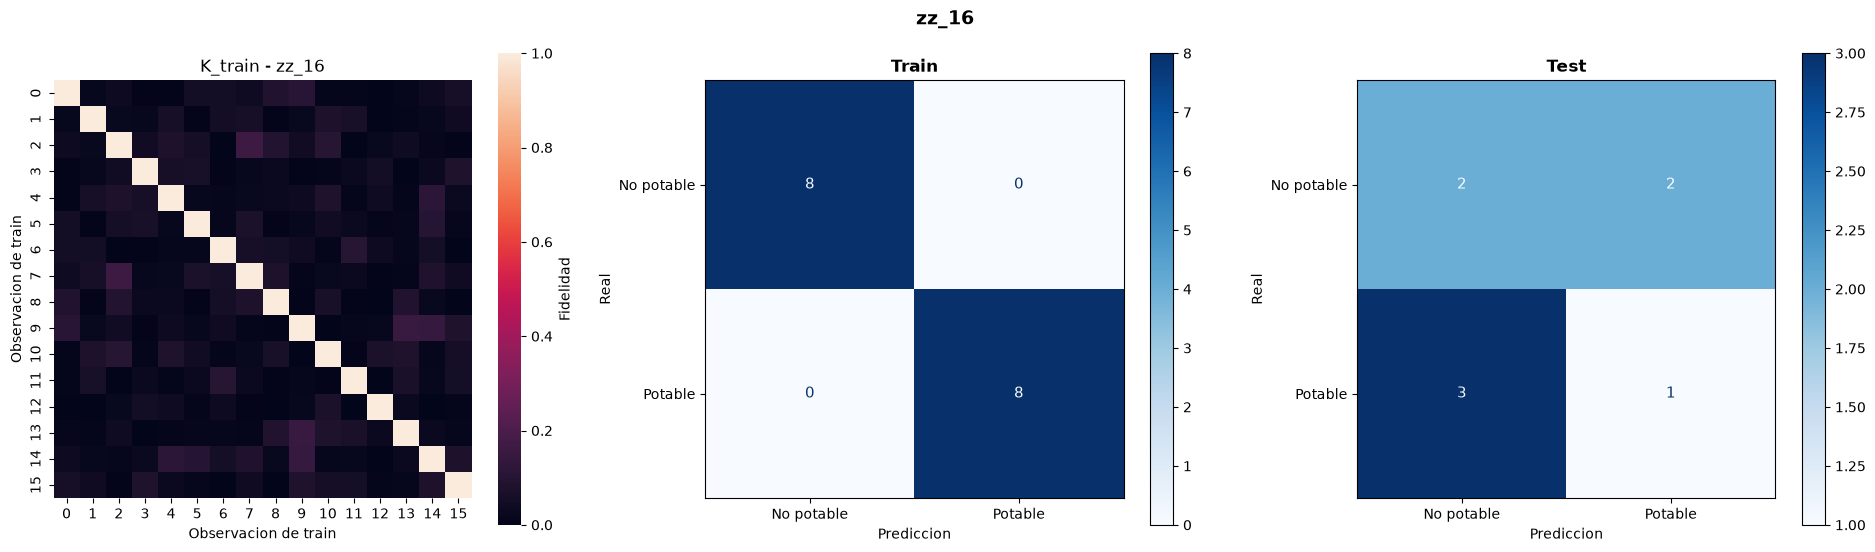

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,1.000,0.375,0.625,62.50%
precision,1.000,0.400,0.600,60.00%
recall,1.000,0.500,0.500,50.00%
f1,1.000,0.444,0.556,55.56%
roc_auc,1.000,0.375,0.625,62.50%


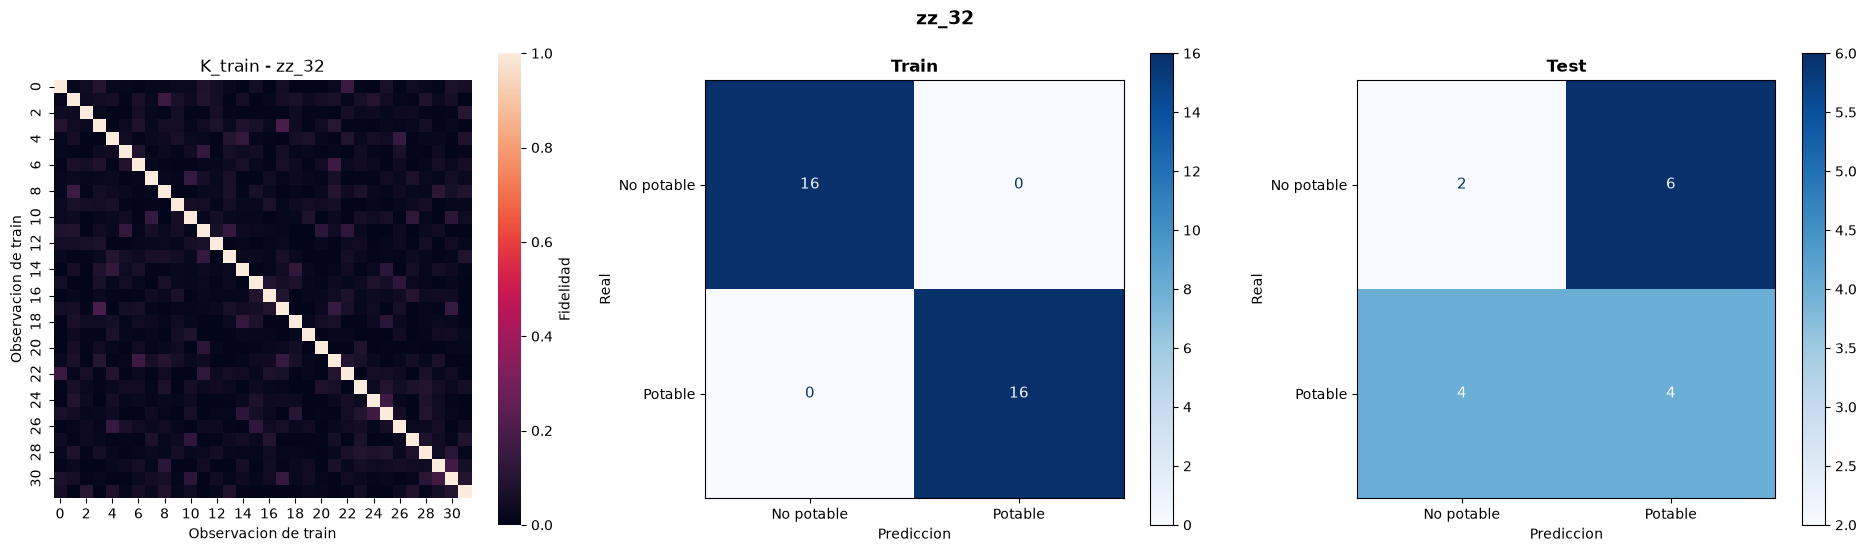

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,1.000,0.625,0.375,37.50%
precision,1.000,0.667,0.333,33.33%
recall,1.000,0.500,0.500,50.00%
f1,1.000,0.571,0.429,42.86%
roc_auc,1.000,0.688,0.312,31.25%


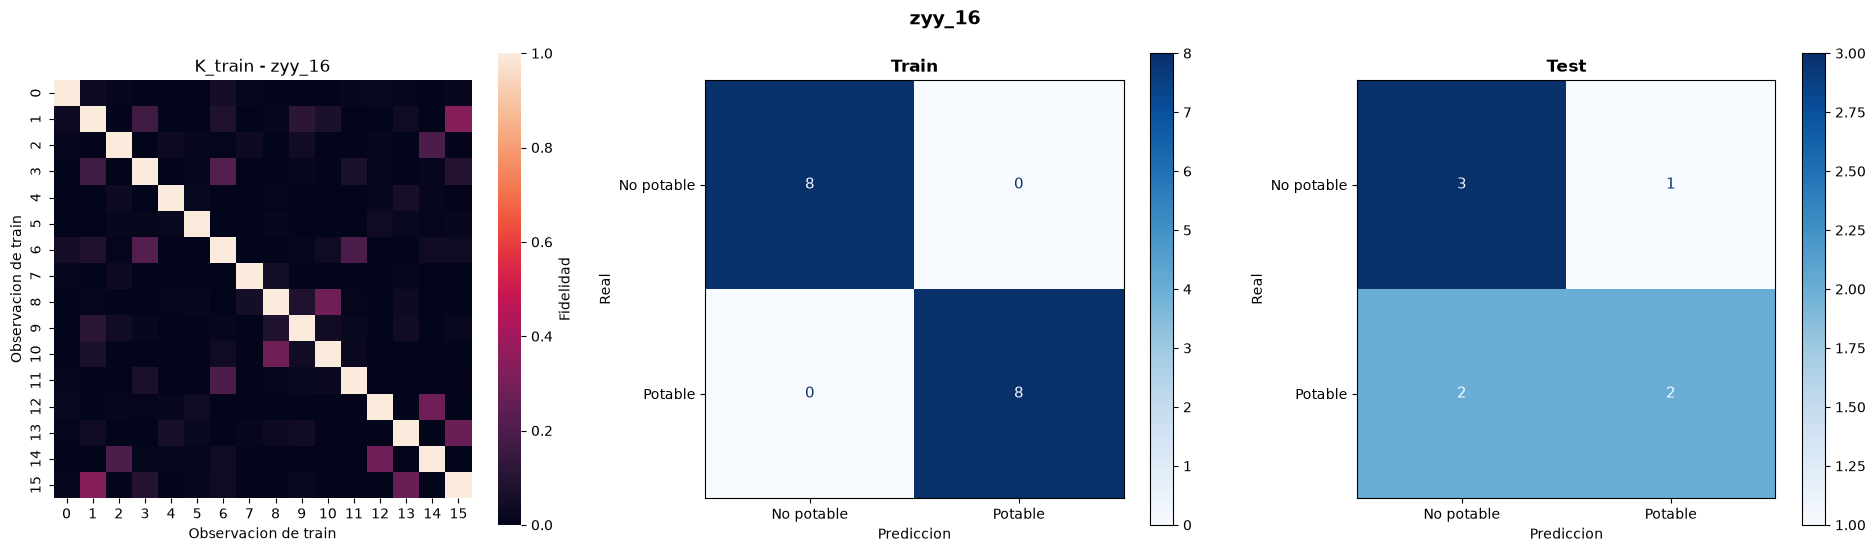

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,1.000,0.625,0.375,37.50%
precision,1.000,0.625,0.375,37.50%
recall,1.000,0.625,0.375,37.50%
f1,1.000,0.625,0.375,37.50%
roc_auc,1.000,0.766,0.234,23.44%


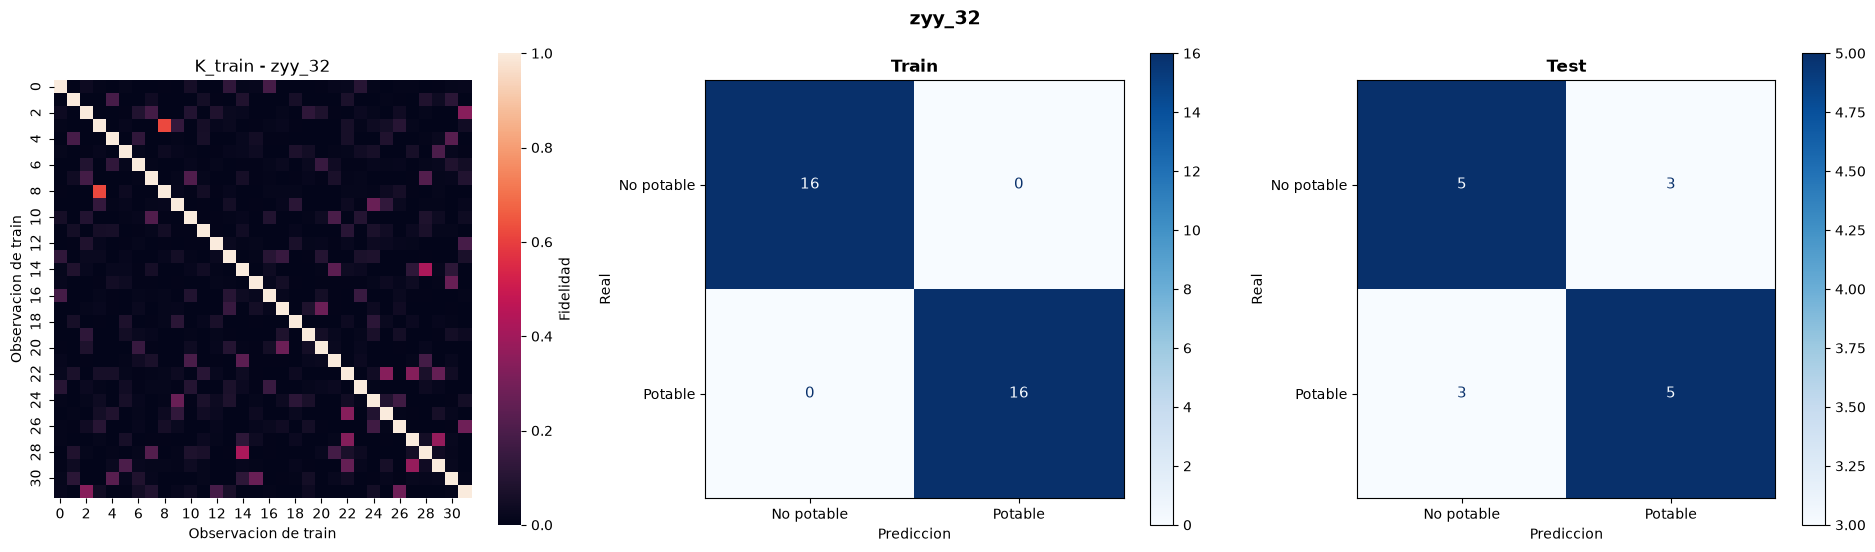

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,0.938,0.375,0.562,60.00%
precision,0.889,0.429,0.460,51.79%
recall,1.000,0.750,0.250,25.00%
f1,0.941,0.545,0.396,42.05%
roc_auc,0.984,0.438,0.547,55.56%


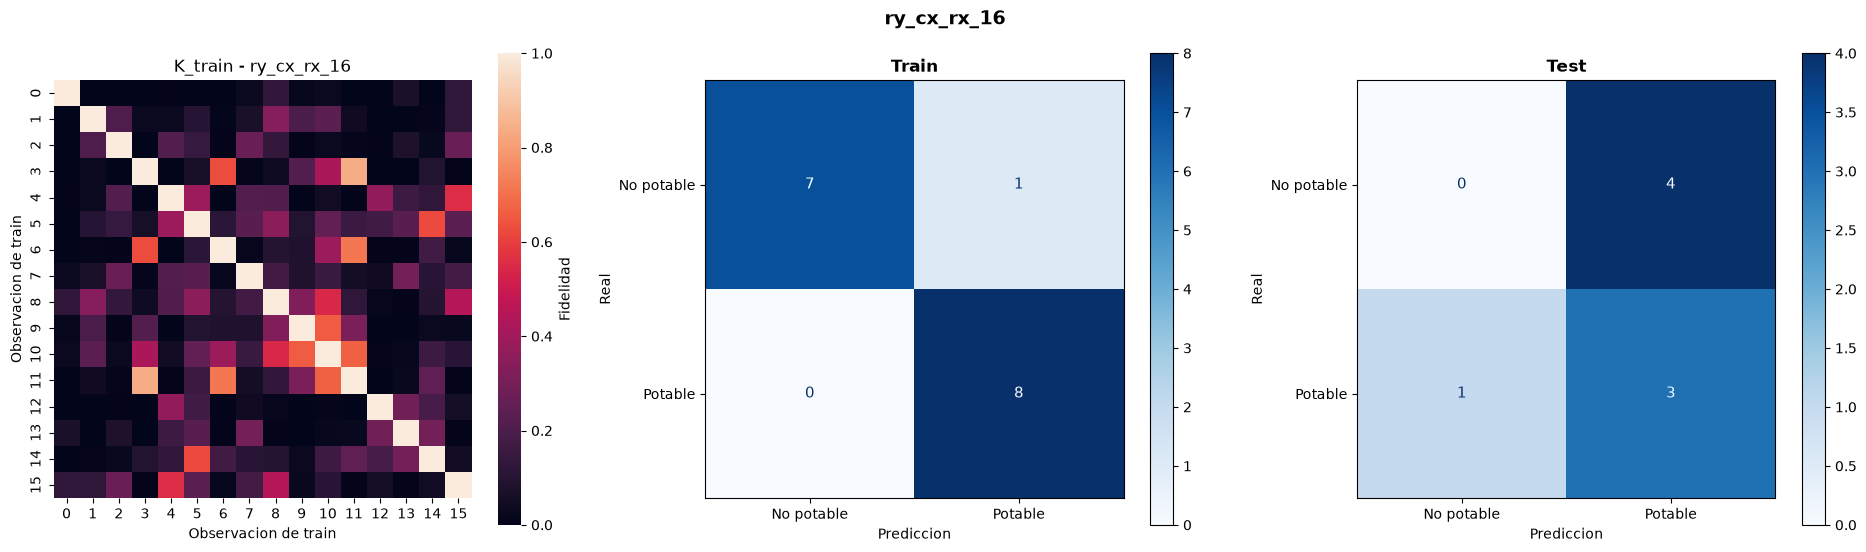

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,0.875,0.375,0.500,57.14%
precision,0.833,0.375,0.458,55.00%
recall,0.938,0.375,0.562,60.00%
f1,0.882,0.375,0.507,57.50%
roc_auc,0.965,0.484,0.480,49.80%


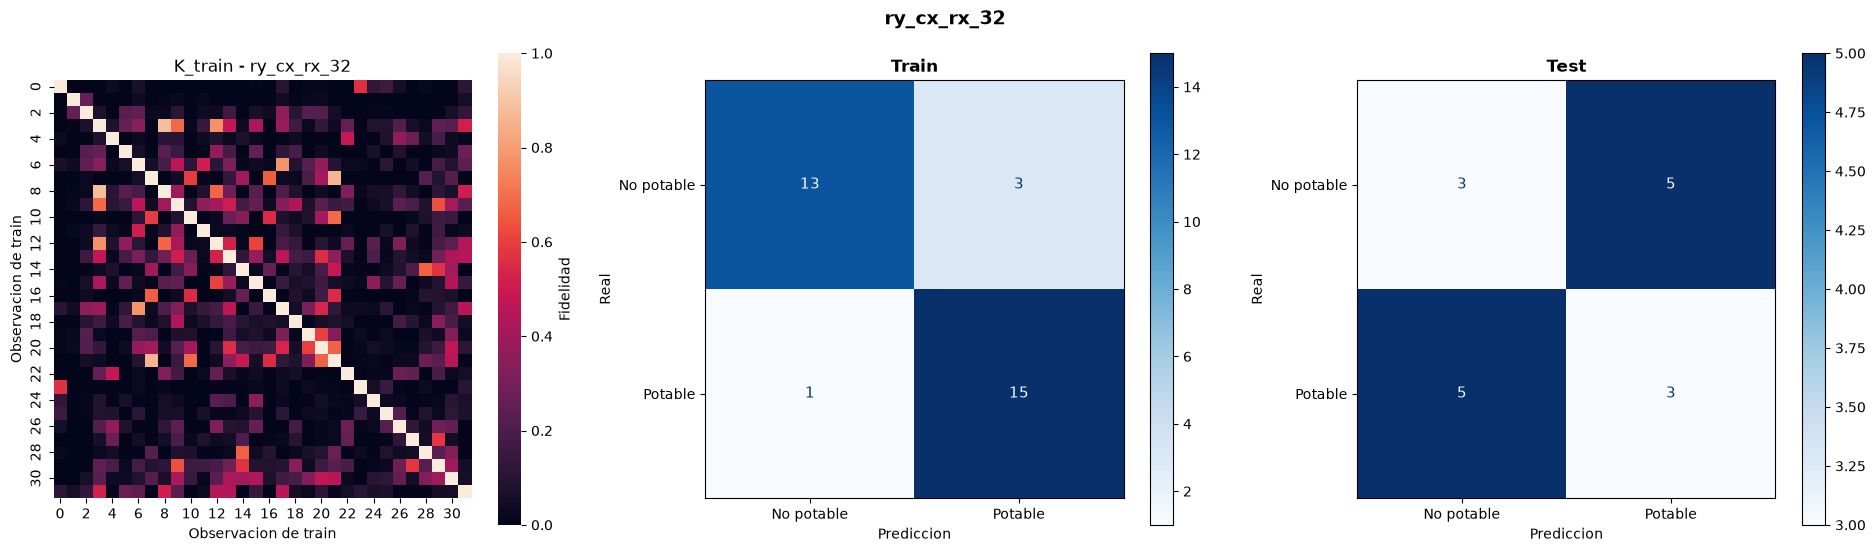

In [72]:
from funciones import (
    etiquetas_familia,
    evaluar_familia_qsvm,
    graficar_resultado_familia,
    parsear_familia,
    comparar_metricas_train_test,
)

resumen_familias = []
# Resultados y etiquetas por familia, reutilizados en el Paso 4
# (comparacion contra el SVM clasico) sin recalcular el QSVM.
resultados_qsvm_por_familia = {}
etiquetas_por_familia = {}

for seccion, familia in enumerate(FAMILIAS, start=1):
    feature_map, tamano, _rt, _rte = parsear_familia(familia)
    clave = f"{feature_map}_{tamano}"

    K_train = K_train_por_familia[clave].to_numpy(dtype=float)
    K_test = K_test_por_familia[clave].to_numpy(dtype=float)
    y_train, y_test = etiquetas_familia(muestreo_df, tamano, NIVEL_POR_TAMANO)

    resultado = evaluar_familia_qsvm(K_train, y_train, K_test, y_test)
    resultados_qsvm_por_familia[clave] = resultado
    etiquetas_por_familia[clave] = (y_train, y_test)

    # Comparacion train vs test (brecha de overfitting) de esta familia.
    display(comparar_metricas_train_test(
        resultado["metrics_train"], resultado["metrics_test"]
    ))

    fig, _ = graficar_resultado_familia(
        K_train, y_train, resultado["y_pred_train"],
        y_test, resultado["y_pred_test"], clave,
    )
    fig.savefig(f"{IMG_DIR}/03_{seccion:02d}_resultado_{clave}.png", dpi=150, bbox_inches="tight")
    plt.show()

    metrics_test = resultado["metrics_test"]
    resumen_familias.append({
        "Familia": clave,
        "n-sample (train)": K_train.shape[0],
        "Mejor C": resultado["mejor_C"],
        "f1 test": metrics_test["f1"],
        "precision test": metrics_test["precision"],
        "recall test": metrics_test["recall"],
        "accuracy": metrics_test["accuracy"],
        "auc": metrics_test["roc_auc"],
    })

## 3.3 Tabla resumen

Metricas de test de las 6 familias, ordenadas por f1 de test (descendente).

In [73]:
tabla_resumen = (
    pd.DataFrame(resumen_familias)
    .sort_values("f1 test", ascending=False)
    .reset_index(drop=True)
)
tabla_resumen

,Familia,n-sample (train),Mejor C,f1 test,precision test,recall test,accuracy,auc
0,zyy_32,32,1.000000,0.625000,0.625000,0.625,0.625,0.765625
1,zyy_16,16,1.000000,0.571429,0.666667,0.500,0.625,0.687500
2,ry_cx_rx_16,16,0.100000,0.545455,0.428571,0.750,0.375,0.437500
3,zz_32,32,10.000000,0.444444,0.400000,0.500,0.375,0.375000
4,ry_cx_rx_32,32,1.000000,0.375000,0.375000,0.375,0.375,0.484375
5,zz_16,16,0.000001,0.285714,0.333333,0.250,0.375,0.312500


# Paso 4. SVM clasico comparativo

Un SVM clasico (RBF) entrenado con la misma cantidad de registros que cada familia QSVM (16 u 32), para comparar el rendimiento del kernel cuantico contra un baseline clasico bajo identica cantidad de datos. El SVM clasico no depende del feature map, asi que basta un entrenamiento por tamano de muestra (no por familia). La comparacion grafica se enfoca en la mejor familia QSVM de cada tamano (2 figuras, no las 6); la tabla comparativa completa de las 6 familias queda al final del cuaderno (4.4).

## 4.1 Entrenar SVM clasico por tamano de muestra

La busqueda de hiperparametros usa el mismo mecanismo de cache que el resto del cuaderno (`evaluar_grid_search`), asi que no se recalcula si ya existe un resultado para esos datos/modelo/grid.

In [74]:
from funciones import entrenar_svm_muestra, parsear_familia

TAMANOS_UNICOS = sorted({parsear_familia(f)[1] for f in FAMILIAS})

svm_por_tamano = {
    tamano: entrenar_svm_muestra(muestreo_df, variables_finales, tamano, NIVEL_POR_TAMANO)
    for tamano in TAMANOS_UNICOS
}

[evaluar_grid_search] Cache existente en 'cache\evaluar_grid_search_55b4754ac1e6aeecf14564e60cf5e887.json': se cargan los resultados guardados.
[evaluar_grid_search] Cache existente en 'cache\evaluar_grid_search_29886521dab971d11818c15bb7a6c09a.json': se cargan los resultados guardados.


## 4.2 Mejor familia QSVM por tamano vs SVM clasico (figuras)

Para cada tamano de muestra, se identifica la familia QSVM con mayor f1 de test (entre los 3 feature maps) y se compara contra el SVM clasico del mismo tamano: 2 figuras en total, cada una con las 4 matrices de confusion en una fila (QSVM train, QSVM test, SVM train, SVM test). Guardadas en `data/img/04_0N_comparacion_mejor_<tamano>.png`.

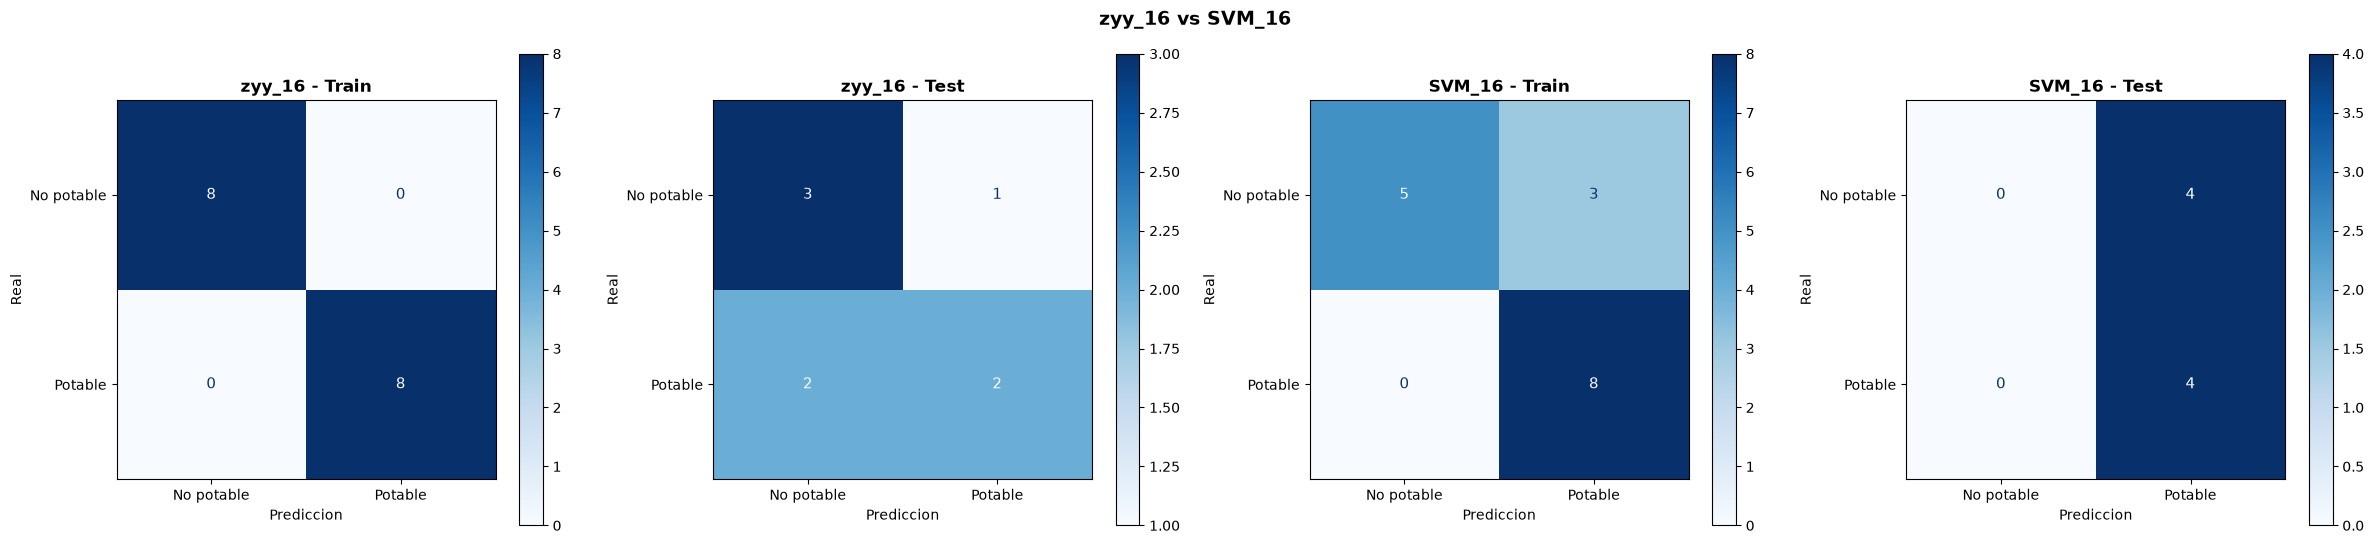

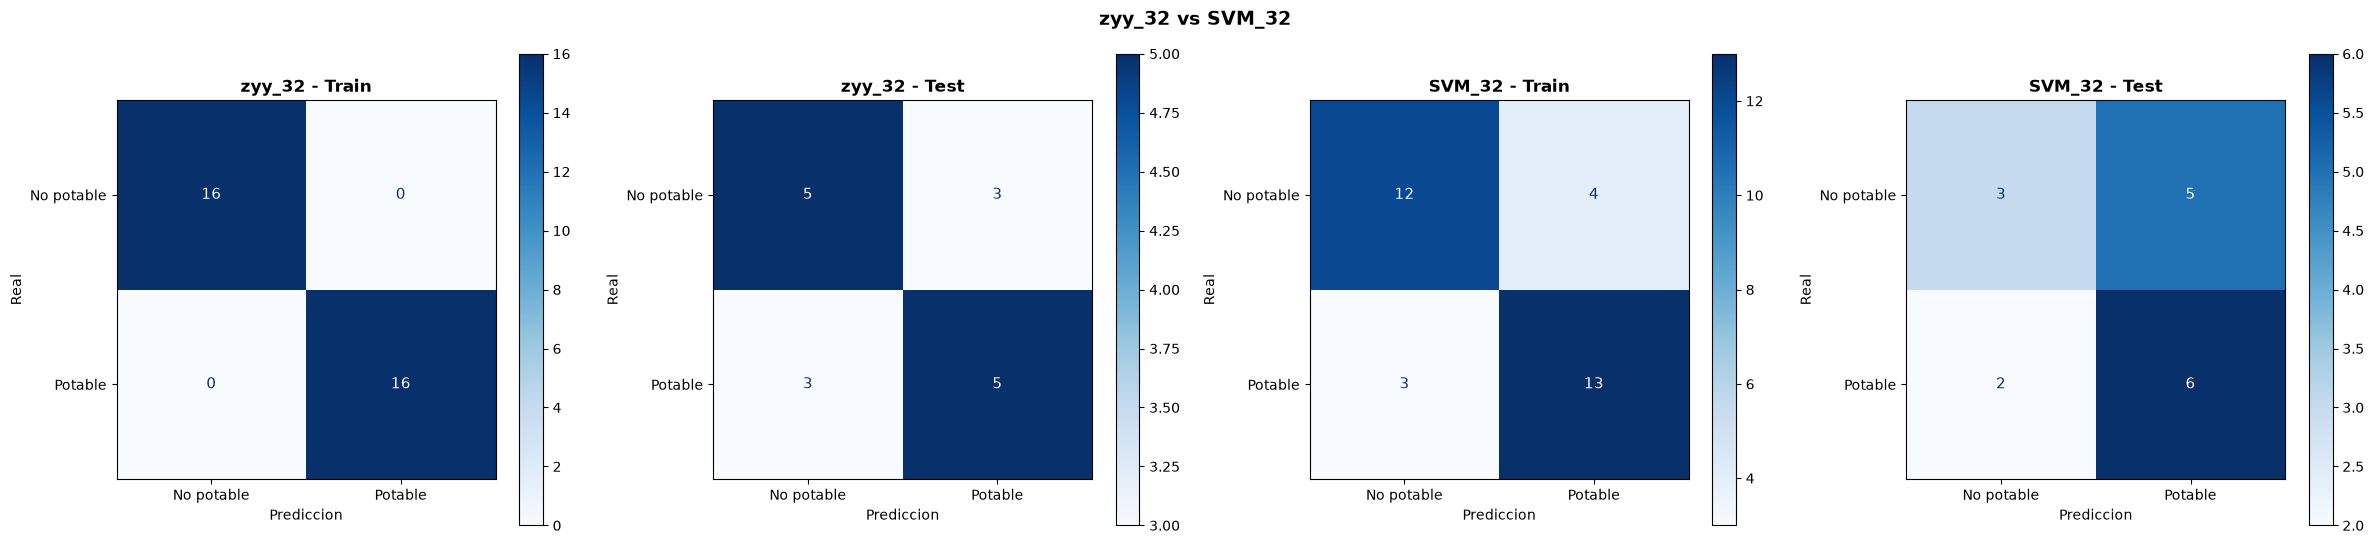

In [75]:
from funciones import graficar_comparacion_familia

# Mejor familia QSVM (mayor f1 test) por tamano de muestra.
mejor_por_tamano = {
    tamano: max(
        (fila for fila in resumen_familias if fila["n-sample (train)"] == tamano),
        key=lambda fila: fila["f1 test"],
    )
    for tamano in TAMANOS_UNICOS
}

for seccion, tamano in enumerate(TAMANOS_UNICOS, start=1):
    mejor = mejor_por_tamano[tamano]
    clave = mejor["Familia"]

    resultado_qsvm = resultados_qsvm_por_familia[clave]
    y_train, y_test = etiquetas_por_familia[clave]
    resultado_svm = svm_por_tamano[tamano]

    fig, _ = graficar_comparacion_familia(
        y_train, resultado_qsvm["y_pred_train"],
        y_test, resultado_qsvm["y_pred_test"],
        resultado_svm["y_pred_train"], resultado_svm["y_pred_test"],
        clave, f"SVM_{tamano}",
    )
    fig.savefig(f"{IMG_DIR}/04_{seccion:02d}_comparacion_mejor_{tamano}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4.3 Tabla comparativa: mejor QSVM vs SVM por tamano

Solo las 2 filas (una por tamano) de la mejor familia QSVM contra el SVM clasico del mismo tamano. `delta_f1 (QSVM - SVM)` positivo indica que el QSVM supera a su baseline clasico.

In [76]:
resumen_mejores = []
for tamano in TAMANOS_UNICOS:
    mejor = mejor_por_tamano[tamano]
    metrics_svm = svm_por_tamano[tamano]["metrics_test"]
    resumen_mejores.append({
        "Tamano": tamano,
        "Mejor familia QSVM": mejor["Familia"],
        "f1 test (QSVM)": mejor["f1 test"],
        "f1 test (SVM)": metrics_svm["f1"],
        "delta_f1 (QSVM - SVM)": mejor["f1 test"] - metrics_svm["f1"],
        "precision test (QSVM)": mejor["precision test"],
        "precision test (SVM)": metrics_svm["precision"],
        "recall test (QSVM)": mejor["recall test"],
        "recall test (SVM)": metrics_svm["recall"],
        "accuracy (QSVM)": mejor["accuracy"],
        "accuracy (SVM)": metrics_svm["accuracy"],
        "auc (QSVM)": mejor["auc"],
        "auc (SVM)": metrics_svm["roc_auc"],
    })

tabla_mejores = pd.DataFrame(resumen_mejores)
tabla_mejores

,Tamano,Mejor familia QSVM,f1 test (QSVM),f1 test (SVM),delta_f1 (QSVM - SVM),precision test (QSVM),precision test (SVM),recall test (QSVM),recall test (SVM),accuracy (QSVM),accuracy (SVM),auc (QSVM),auc (SVM)
0,16,zyy_16,0.571429,0.666667,-0.095238,0.666667,0.500000,0.500,1.00,0.625,0.5000,0.687500,0.25
1,32,zyy_32,0.625000,0.631579,-0.006579,0.625000,0.545455,0.625,0.75,0.625,0.5625,0.765625,0.50


## 4.4 Tabla comparativa extendida (todas las familias)

Extiende la tabla resumen del Paso 3 (3.3) con las metricas de test del SVM clasico del mismo tamano, para las 6 familias. `delta_f1 (QSVM - SVM)` positivo indica que esa familia QSVM supera a su baseline clasico. Ordenada por f1 de test del QSVM (descendente).

In [77]:
resumen_comparativo = []
for fila in resumen_familias:
    tamano = fila["n-sample (train)"]
    metrics_svm = svm_por_tamano[tamano]["metrics_test"]

    fila_extendida = dict(fila)
    fila_extendida.update({
        "Mejor C (SVM)": svm_por_tamano[tamano]["mejores_parametros"]["C"],
        "f1 test (SVM)": metrics_svm["f1"],
        "precision test (SVM)": metrics_svm["precision"],
        "recall test (SVM)": metrics_svm["recall"],
        "accuracy (SVM)": metrics_svm["accuracy"],
        "auc (SVM)": metrics_svm["roc_auc"],
        "delta_f1 (QSVM - SVM)": fila["f1 test"] - metrics_svm["f1"],
    })
    resumen_comparativo.append(fila_extendida)

tabla_comparativa = (
    pd.DataFrame(resumen_comparativo)
    .sort_values("f1 test", ascending=False)
    .reset_index(drop=True)
)
tabla_comparativa

,Familia,n-sample (train),Mejor C,f1 test,precision test,recall test,accuracy,auc,Mejor C (SVM),f1 test (SVM),precision test (SVM),recall test (SVM),accuracy (SVM),auc (SVM),delta_f1 (QSVM - SVM)
0,zyy_32,32,1.000000,0.625000,0.625000,0.625,0.625,0.765625,1.0,0.631579,0.545455,0.75,0.5625,0.50,-0.006579
1,zyy_16,16,1.000000,0.571429,0.666667,0.500,0.625,0.687500,0.1,0.666667,0.500000,1.00,0.5000,0.25,-0.095238
2,ry_cx_rx_16,16,0.100000,0.545455,0.428571,0.750,0.375,0.437500,0.1,0.666667,0.500000,1.00,0.5000,0.25,-0.121212
3,zz_32,32,10.000000,0.444444,0.400000,0.500,0.375,0.375000,1.0,0.631579,0.545455,0.75,0.5625,0.50,-0.187135
4,ry_cx_rx_32,32,1.000000,0.375000,0.375000,0.375,0.375,0.484375,1.0,0.631579,0.545455,0.75,0.5625,0.50,-0.256579
5,zz_16,16,0.000001,0.285714,0.333333,0.250,0.375,0.312500,0.1,0.666667,0.500000,1.00,0.5000,0.25,-0.380952
